In [1]:
import pandas as pd

df_car_fuel = pd.read_csv('car_fuel_efficiency_2026.csv')
df_car_fuel.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


# Preparing the dataset

In [11]:
# reduce the dataframe to the subset of columns that will be used:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df_car_fuel_base = df_car_fuel[base]
df_car_fuel_base.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [21]:
import numpy as np

def prepare_data_sets(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    return df_train, df_val, df_test

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

## EDA of fuel_efficiency_mpg

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

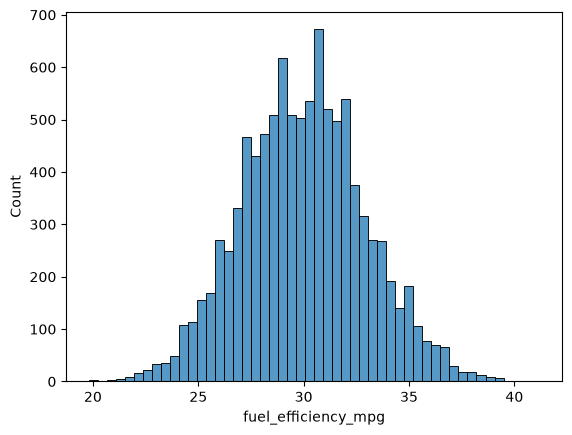

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

#The %matplotlib inline line makes sure the plots are displayed in the notebook
%matplotlib inline
sns.histplot(df_car_fuel_base.fuel_efficiency_mpg, bins=50)

# Question 1: Missing values

In [13]:
df_car_fuel_base.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

# Question 2: Median for horsepower

In [14]:
df_car_fuel_base.horsepower.median()

np.float64(254.0)

# Question 3: Filling NAs

## Preparing datasets

In [15]:
df_train, df_val, df_test = prepare_data_sets(df_car_fuel_base, 42)
#
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

## Training using data that filled NA with zeros

In [31]:
X_train_filled_0 = df_train.fillna(0).values
X_val_filled_0 = df_val.fillna(0).values

w0_filled_0, w_filled_0 = train_linear_regression(X_train_filled_0, y_train)
w0_filled_0, w_filled_0


(np.float64(-153.8849618823138),
 array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01]))

## Training using data that filled NA with median

In [32]:
X_train_median = df_train.horsepower.median()
X_train_filled_median = df_train.fillna(X_train_median).values
X_val_filled_median = df_val.fillna(X_train_median).values

w0_filled_median, w_filled_median = train_linear_regression(X_train_filled_median, y_train)
w0_filled_median, w_filled_median

(np.float64(-153.34000048862066),
 array([-0.00102491, -0.00647299, -0.00388832,  0.10200021]))

## Comparing using a graph

<Axes: ylabel='Count'>

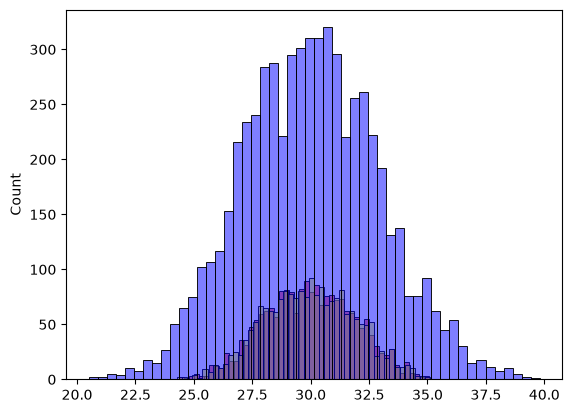

In [33]:
y_pred_filled_0 = w0_filled_0 + X_val_filled_0.dot(w_filled_0)
y_pred_filled_median = w0_filled_median + X_val_filled_median.dot(w_filled_median)

sns.histplot(y_pred_filled_0, color='red', alpha=0.5, bins=50)
sns.histplot(y_pred_filled_median, color='yellow', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

## Comparing using RMSE

In [35]:
RMSE_pred_filled_0  = rmse(y_val, y_pred_filled_0)
round(RMSE_pred_filled_0, 3)

np.float64(2.205)

In [36]:
RMSE_pred_filled_median = rmse(y_val, y_pred_filled_median)
round(RMSE_pred_filled_median, 3)

np.float64(2.202)

# Question 4: Best regularization

In [42]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

# fill the NAs with 0
def prepare_X(df):
    df_num = df.copy()
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [49]:
rs = [0, 0.01, 0.1, 1, 5, 10, 100]

for rv in rs:
    X_train = prepare_X(df_train)
    w0_r, w_r = train_linear_regression_reg(X_train, y_train, r=rv)

    X_val = prepare_X(df_val)
    y_pred_r = w0_r + X_val.dot(w_r)
    score = rmse(y_val, y_pred_r)
    print(rv, "RMSE:", round(score, 3))

0 RMSE: 2.205
0.01 RMSE: 2.206
0.1 RMSE: 2.224
1 RMSE: 2.349
5 RMSE: 2.409
10 RMSE: 2.419
100 RMSE: 2.429


# Question 5: RMSE standard deviation

In [51]:
#Try different seed values:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []

for seed in seeds:
    df_train_seed, df_val_seed, df_test_seed = prepare_data_sets(df_car_fuel_base, seed)
    y_train_seed = df_train_seed.fuel_efficiency_mpg.values
    y_val_seed = df_val_seed.fuel_efficiency_mpg.values
    y_test_seed = df_test_seed.fuel_efficiency_mpg.values
    del df_train_seed['fuel_efficiency_mpg']
    del df_val_seed['fuel_efficiency_mpg']
    del df_test_seed['fuel_efficiency_mpg']

    X_train_seed = prepare_X(df_train_seed)
    w0_seed, w_seed = train_linear_regression(X_train_seed, y_train_seed)

    X_val_seed = prepare_X(df_val_seed)
    y_pred_seed = w0_seed + X_val_seed.dot(w_seed)
    score_seed = rmse(y_val_seed, y_pred_seed)
    scores.append(score_seed)
    print("Seed:", seed, "RMSE:", round(score_seed, 3))

print("Standard deviation of RMSE:", np.std(scores))

Seed: 0 RMSE: 2.239
Seed: 1 RMSE: 2.202
Seed: 2 RMSE: 2.163
Seed: 3 RMSE: 2.204
Seed: 4 RMSE: 2.202
Seed: 5 RMSE: 2.246
Seed: 6 RMSE: 2.27
Seed: 7 RMSE: 2.191
Seed: 8 RMSE: 2.217
Seed: 9 RMSE: 2.207
Standard deviation of RMSE: 0.028781274078191175


# Question 6: Evaluation on test

In [53]:
#Split the dataset like previously, use seed 9.
df_train_seed_9, df_val_seed_9, df_test_seed_9 = prepare_data_sets(df_car_fuel_base, 9)

#Combine train and validation datasets.
df_full_train_seed_9 = pd.concat([df_train_seed_9, df_val_seed_9])
y_full_train_seed_9 = df_full_train_seed_9.fuel_efficiency_mpg.values
del df_full_train_seed_9['fuel_efficiency_mpg']
y_test_seed_9 = df_test_seed_9.fuel_efficiency_mpg.values
del df_test_seed_9['fuel_efficiency_mpg']

#Fill the missing values with 0
X_full_train_seed_9 = prepare_X(df_full_train_seed_9)
X_test_seed_9 = prepare_X(df_test_seed_9)

# train a model with r=0.001
w0_full_train_seed_9, w_full_train_seed_9 = train_linear_regression_reg(X_full_train_seed_9, y_full_train_seed_9, r=0.001)

#Evaluate the model on the test dataset
y_pred_full_train_seed_9 = w0_full_train_seed_9 + X_test_seed_9.dot(w_full_train_seed_9)
rmse(y_test_seed_9, y_pred_full_train_seed_9)







np.float64(2.235827747191731)